# Plot model output

started 2023-05-12
by Eva Lieungh, Lasse T. Keetz, chatGPT

Notebook copied and modified from the [LSP](https://github.com/NorESMhub/noresm-land-sites-platform), which again is inspired from other sources like CTSM and FATES tutorials (e.g. [NCAR/ctsm_python_gallery](https://github.com/NCAR/ctsm_python_gallery)).

Prerequisite: Concatenate history files (one file per month of the simulation) into a single file. Notebook in ../data_handling

In this notebook:
1. read in concatenated output files from five simulations from the manuscript
2. plot aboveground biomass per PFT in all simulations
3. plot productivity / carbon fluxes in all simulations

In [1]:
import xarray as xr  # NetCDF data handling
import matplotlib.pyplot as plt  # Plotting
import time  # Keeping track of runtime
import json  # For reading data dictionaries stored in json format
import datetime as dt  # for workaround with long simulations (beyond year 2262)
from pathlib import Path
import pandas as pd
import numpy as np

Define names and paths to the NetCDF output. First print the current working directory, should be myforderstructure/FATES_INCLINE/src/analysis_and_plotting

In [2]:
%%bash
pwd

/mnt/c/Users/evaler/OneDrive - Universitetet i Oslo/Eva/PHD/3_FATES_INCLINE/FATES_INCLINE/src/analysis_and_plotting


In [ ]:
# Set simulation (case) names
cold = "cold"
warm = "warm"
exp_c = "experiment"
exp_w = "experimentwarm"

Enter the file path and names of the output files. Download data from zenodo and place it in the results folder!

In [4]:
# Path to concatenated land archive output
output_data_path = f"../../results"

# Enter the names of single output files from each simulation.
file_path_cold = f"{output_data_path}/cold.h0.concatenated_nc4.nc"
file_path_exp_c = f"{output_data_path}/experiment.h0.concatenated_nc4.nc"

In [6]:
# check that it looks correct
file_path_cold

'../../results/cold.h0.concatenated_nc4.nc'

Read in the data files

In [ ]:
file_paths = {
    'cold': file_path_cold,
#    'warm': file_path_warm,
    'exp_c': file_path_exp_c#,
#    'exp_w': file_path_exp_w
}

data = {}

for dataset, path in file_paths.items():
    data[dataset] = xr.open_mfdataset(path, 
                                      combine='by_coords', 
                                      decode_times=True)

Define folder for the case's output plots

In [9]:
# set folder
plot_save_path = Path("../../results/figures/")

if not plot_save_path.is_dir():
    plot_save_path.mkdir(parents=True, 
                         exist_ok=True)

### Data set exploration
The code cell below prints relevant information about a NetCDF file with the `xarray` package. Note that you can click in the printed information below to display more informaton.

In [10]:
# Print full dataset information
data["cold"]

<xarray.Dataset>
Dimensions:                             (levgrnd: 25, levsoi: 20, levlak: 10,
                                         levdcmp: 25, fates_levscls: 13,
                                         fates_levscag: 91, fates_levscpf: 26,
                                         fates_levcacls: 2, fates_levcapf: 4,
                                         fates_levage: 7, fates_levheight: 6,
                                         fates_levpft: 2, fates_levfuel: 6,
                                         ...
                                         fates_levcdsc: 26, fates_levcdpf: 52,
                                         fates_levcdam: 2, fates_levlanduse: 5,
                                         time: 2712, nbnd: 2, lndgrid: 1,
                                         fates_levelcwd: 4, fates_levelem: 1,
                                         fates_levlulu: 25, glc_nec: 10,
                                         ltype: 9, numrad: 2)
Coordinates: (12/16)
  * levgrnd                             (levgrnd) float32 0.01 0.04 ... 42.0
  * levsoi                              (levsoi) float32 0.01 0.04 ... 6.94 8.03
  * levlak                              (levlak) float32 0.05 0.6 ... 44.78
  * levdcmp                             (levdcmp) float32 0.01 0.04 ... 42.0
  * fates_levscls                       (fates_levscls) float32 0.0 ... 100.0
  * fates_levcacls                      (fates_levcacls) float32 0.0 5.0
    ...                                  ...
  * fates_levcwdsc                      (fates_levcwdsc) int32 1 2 3 4
  * fates_levcan                        (fates_levcan) int32 1 2
  * fates_levleaf                       (fates_levleaf) int32 0 1 1 ... 67 74 82
  * fates_levcdam                       (fates_levcdam) float32 0.0 80.0
  * fates_levlanduse                    (fates_levlanduse) int32 1 2 3 4 5
  * time                                (time) object 1901-01-16 12:00:00 ......
Dimensions without coordinates: fates_levscag, fates_levscpf, fates_levcapf,
                                fates_levcnlf, fates_levcnlfpf,
                                fates_levscagpf, fates_levagepft,
                                fates_levagefuel, fates_levcdsc, fates_levcdpf,
                                nbnd, lndgrid, fates_levelcwd, fates_levelem,
                                fates_levlulu, glc_nec, ltype, numrad
Data variables: (12/551)
    fates_scmap_levscag                 (fates_levscag) int32 dask.array<chunksize=(91,), meta=np.ndarray>
    fates_agmap_levscag                 (fates_levscag) int32 dask.array<chunksize=(91,), meta=np.ndarray>
    fates_pftmap_levscpf                (fates_levscpf) int32 dask.array<chunksize=(26,), meta=np.ndarray>
    fates_scmap_levscpf                 (fates_levscpf) int32 dask.array<chunksize=(26,), meta=np.ndarray>
    fates_pftmap_levcapf                (fates_levcapf) int32 dask.array<chunksize=(4,), meta=np.ndarray>
    fates_camap_levcapf                 (fates_levcapf) int32 dask.array<chunksize=(4,), meta=np.ndarray>
    ...                                  ...
    SOM_SLO_C_vr                        (time, levsoi, lndgrid) float32 dask.array<chunksize=(2712, 20, 1), meta=np.ndarray>
    T_SCALAR                            (time, levsoi, lndgrid) float32 dask.array<chunksize=(2712, 20, 1), meta=np.ndarray>
    W_SCALAR                            (time, levsoi, lndgrid) float32 dask.array<chunksize=(2712, 20, 1), meta=np.ndarray>
    PCT_LANDUNIT                        (time, ltype, lndgrid) float32 dask.array<chunksize=(2712, 9, 1), meta=np.ndarray>
    ALBGRD                              (time, numrad, lndgrid) float32 dask.array<chunksize=(2712, 2, 1), meta=np.ndarray>
    ALBGRI                              (time, numrad, lndgrid) float32 dask.array<chunksize=(2712, 2, 1), meta=np.ndarray>
Attributes: (12/37)
    title:                                CLM History file information
    comment:                              NOTE: None of the variables are 

---
# Create simple time series line plots



##### Plot variables with only time and lndgrid dimensions.
There are multiple ways to create output plots from xarray `DataArray` objects, i.e., for all the variables contained in the full xarray `DataSet` that we created when reading in the NetCDF files. For more details, check https://docs.xarray.dev/en/latest/user-guide/plotting.html.

Let's start by selecting one of the `Data variables` from the output above that only has `time` and `lndgrid` dimensions (listed in the parentheses in the second column when you display the data). 

Next, explore your choice by assigning the specific variable object to a new Python variable and by printing its content.

In [11]:
# define variable name for aboveground biomass
AGB_var = "FATES_VEGC_ABOVEGROUND"

# extract AGB from one of the data sets
var = data["cold"][AGB_var]

var

<xarray.DataArray 'FATES_VEGC_ABOVEGROUND' (time: 2712, lndgrid: 1)>
dask.array<open_dataset-83e8aea3b0a3f31ea1529d084b90a055FATES_VEGC_ABOVEGROUND, shape=(2712, 1), dtype=float32, chunksize=(2712, 1), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 1901-01-16 12:00:00 ... 2126-12-16 12:00:00
Dimensions without coordinates: lndgrid
Attributes:
    long_name:      aboveground biomass in kg carbon per m2 land area
    units:          kg m-2
    cell_methods:   time: mean
    landunit_mask:  unknown

When plotting, use a workaround to avoid errors with the time variable

In [12]:
data["cold"].indexes['time']

CFTimeIndex([1901-01-16 12:00:00, 1901-02-15 00:00:00, 1901-03-16 12:00:00,
             1901-04-16 00:00:00, 1901-05-16 12:00:00, 1901-06-16 00:00:00,
             1901-07-16 12:00:00, 1901-08-16 12:00:00, 1901-09-16 00:00:00,
             1901-10-16 12:00:00,
             ...
             2126-03-16 12:00:00, 2126-04-16 00:00:00, 2126-05-16 12:00:00,
             2126-06-16 00:00:00, 2126-07-16 12:00:00, 2126-08-16 12:00:00,
             2126-09-16 00:00:00, 2126-10-16 12:00:00, 2126-11-16 00:00:00,
             2126-12-16 12:00:00],
            dtype='object', length=2712, calendar='noleap', freq='None')

Make a simple plot for one of the simulations:

In [ ]:
# Create year labels for x axis (otherwise shows months since simulation start)
tick_locations = [0, # first year
                  1356, # year 113 (one cycle of climate data)
                  2712]
labels = ['1','113','226']


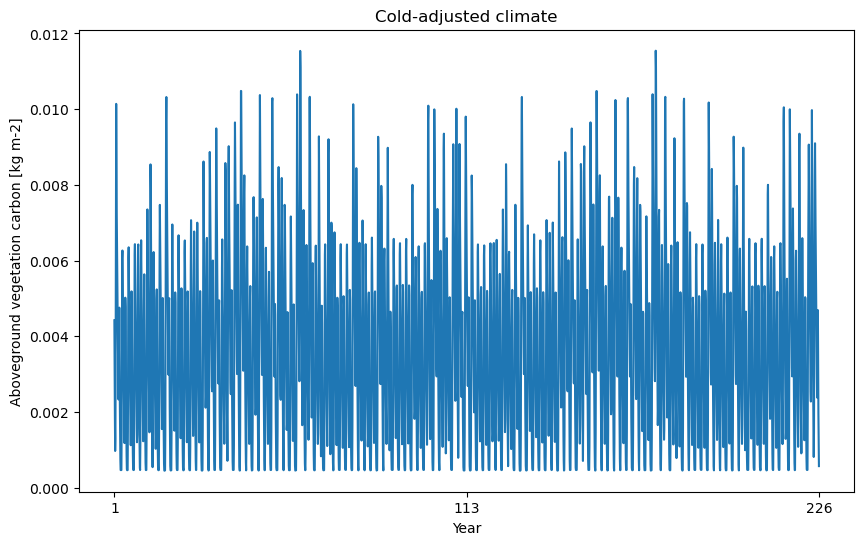

In [14]:
# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(len(data['cold']["time"])), # x axis
        data['cold']["FATES_VEGC_ABOVEGROUND"]) # y axis
ax.set_title(f"Cold-adjusted climate") # simulation name
ax.set_xlabel("Year")
ax.set_ylabel(f"Aboveground vegetation carbon [{data['cold'][AGB_var].units}]")

# Set x-axis tick labels
ax.set_xticks(tick_locations)
ax.set_xticklabels(labels)

plt.show()

And then the same plot but for all the simulations

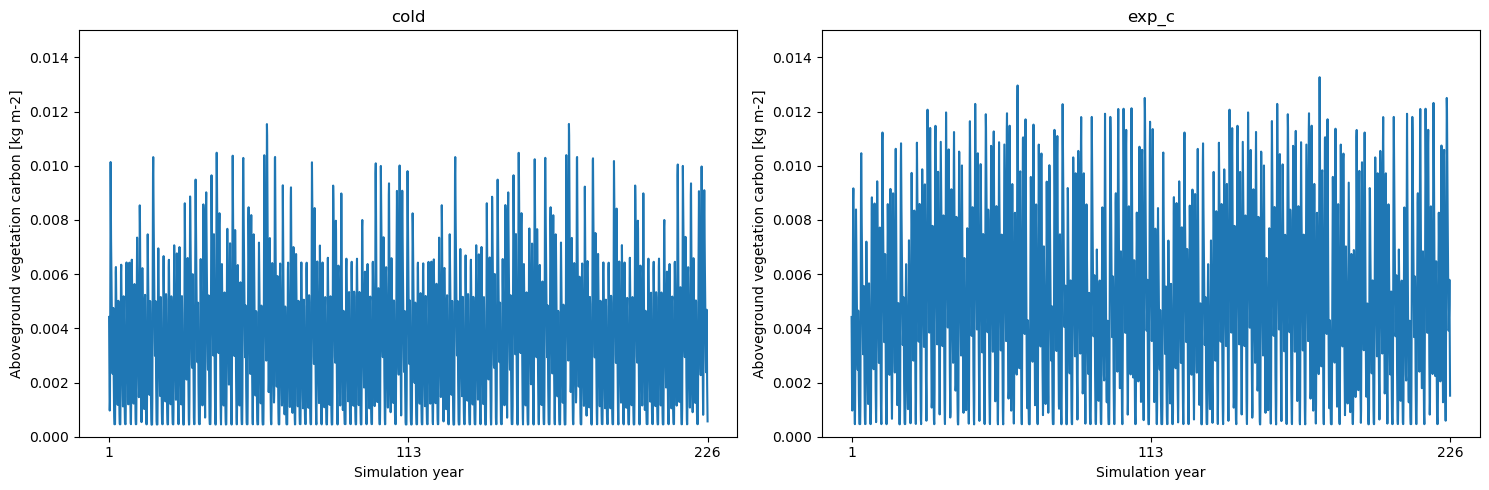

In [16]:
# list simulations
simulations = ['cold', 
               #'warm',
               'exp_c'#,'exp_w'
               ]

# Instantiate figure with individual figures next to each other
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 5)
)

# Delete empty axis object if number of simulations in list is odd
if len(axes.flatten()) != len(simulations):
    if len(axes.flatten()) == 2:
        fig.delaxes(axes[-1])
    else:
        fig.delaxes(axes[-1, -1])

# Plot all variables
for i, simulation in enumerate(simulations):
    ax = axes.flatten()[i]  # Get the appropriate axis object
    ax.plot(range(len(data[simulation]["time"])), 
            data[simulation]["FATES_VEGC_ABOVEGROUND"]) 
    ax.set_title(simulation)
    ax.set_xlabel("Simulation year")
    ax.set_ylabel(f"Aboveground vegetation carbon [{data[simulation]['FATES_VEGC_ABOVEGROUND'].units}]")
    # set y axis limits
    ax.set_ylim([0, 0.015])
    # Set x-axis tick labels
    ax.set_xticks(tick_locations)
    ax.set_xticklabels(labels)

plt.tight_layout()  # Adjust spacing between subplots
plt.show()  # Show the plot

# Subset the last 14 years of the last forcing data cycle (climate from 2000--2014)
There are 226 simulation years, i.e. two cycles of the 1901-2014 forcing data. Values are given as monthly means, so there are 12x226=2712 values. To subset the last 14 years, take the last 14x12=168 values.

In [19]:
subset = {}
for dataset, ds in data.items():
    subset[dataset] = ds.isel(time=slice(-168, None))

### same plots for last 14 years

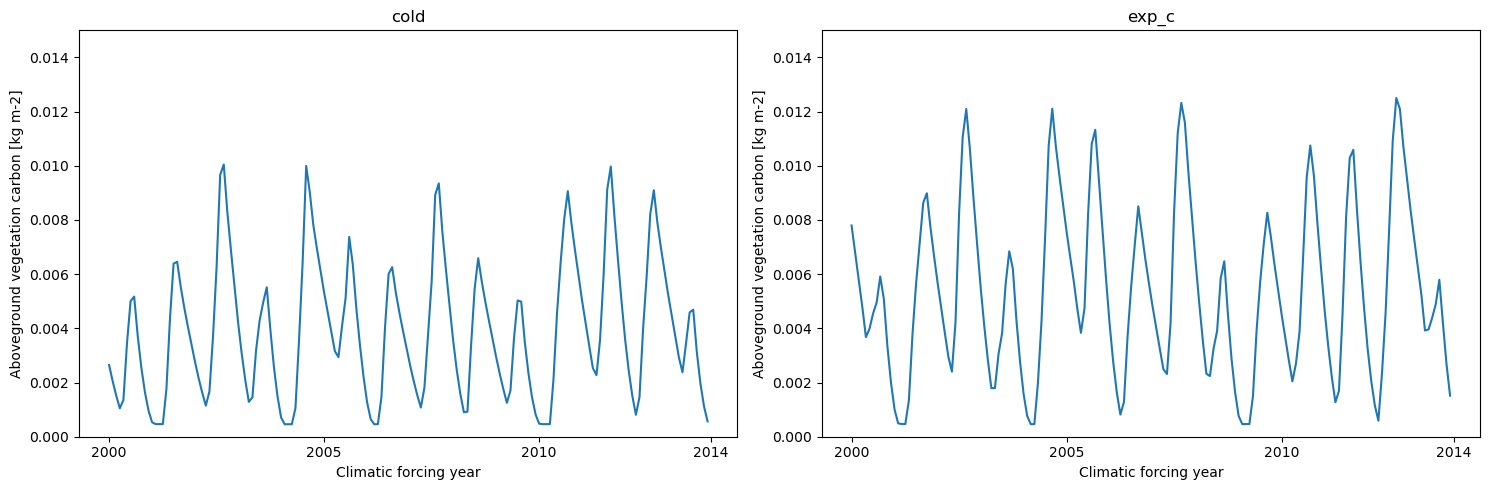

In [33]:
# list simulations
simulations = ['cold', 
               #'warm',
               'exp_c'#,'exp_w'
               ]

# Instantiate figure with individual figures next to each other
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 5)
)

# Create year labels for x axis (otherwise shows month 0-18000)
tick_locations = [0, # first year
                  60, # year 113 (one cycle of climate data)
                  120,
                  168]
labels = ['2000','2005','2010','2014']

# Delete empty axis object if number of simulations in list is odd
if len(axes.flatten()) != len(simulations):
    if len(axes.flatten()) == 2:
        fig.delaxes(axes[-1])
    else:
        fig.delaxes(axes[-1, -1])

# Plot all variables
for i, simulation in enumerate(simulations):
    ax = axes.flatten()[i]  # Get the appropriate axis object
    ax.plot(range(len(subset[simulation]["time"])), 
            subset[simulation]["FATES_VEGC_ABOVEGROUND"]) 
    ax.set_title(simulation)
    ax.set_xlabel("Climatic forcing year")
    ax.set_ylabel(f"Aboveground vegetation carbon [{subset[simulation]['FATES_VEGC_ABOVEGROUND'].units}]")
    # set y axis limits
    ax.set_ylim([0, 0.015])
    # Set x-axis tick labels
    ax.set_xticks(tick_locations)
    ax.set_xticklabels(labels)

plt.tight_layout()  # Adjust spacing between subplots
plt.show()  # Show the plot

---

# Plot biomass (carbon) per PFT
The output variable `FATES_VEGC_PF` stores the amount of total biomass in kg of carbon per land area for each included PFT.

In [23]:
# Variable name for biomass per PFT in dataset
var_name = "FATES_VEGC_PF"


## Simulations with all PFTs

Plot first for the default and improved simulations with *all* PFTs included.

In [29]:
# open dictionary
with open(Path("./dicts/grass_fates_pfts_colors.json"), 'r', encoding='utf-8') as fates_pft_json:
    fates_pft_dict = json.load(fates_pft_json)



#### Default inputs, all PFTs simulation

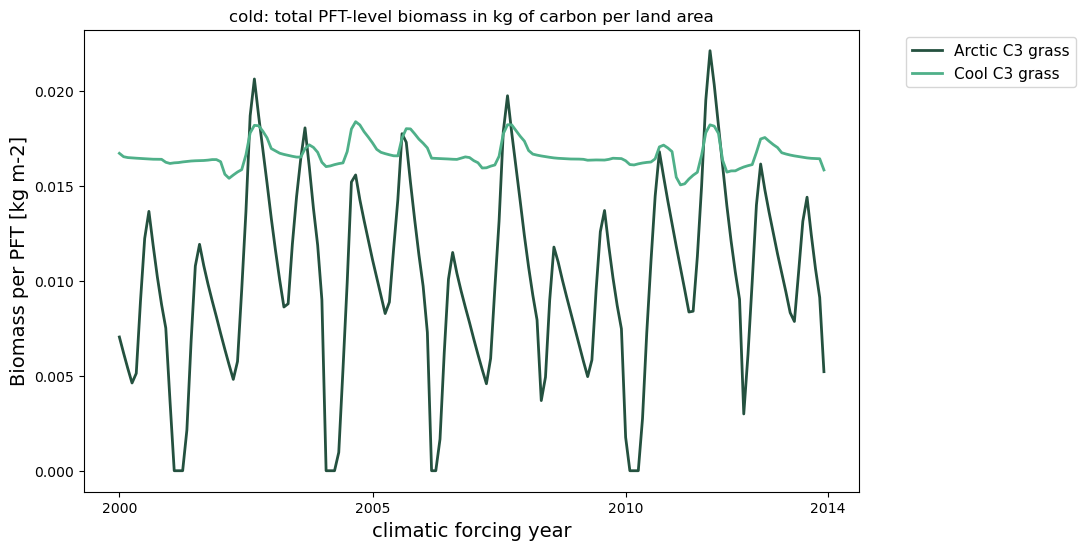

In [34]:
# subset variable from data
pft_biomass = subset["cold"][var_name]

# Instantiate plot
fig, ax = plt.subplots(figsize=(10,6))

# Create a multi-line plot by looping through PFT properties
plot_handle_list = []

# Determine whether default or customized PFTs were used based on boolean variable
pft_dict = fates_pft_dict

for cur_pft_idx in pft_biomass.fates_levpft:
    
    cur_pft_dict = pft_dict[str(int(cur_pft_idx))]
    
    # Plot biomass for current PFT index
    cur_plot_handles, = ax.plot(range(len(pft_biomass["time"])),
                                pft_biomass.sel(fates_levpft=cur_pft_idx),
                                label=cur_pft_dict["long_name"],
                                linestyle="-",
                                linewidth=2,
                                color=cur_pft_dict["colour"]
                               )
    
    plot_handle_list.append(cur_plot_handles)

# Set overall plot layout
ax.set_title(f"{cold}: {pft_biomass.long_name}")
ax.set_xlabel("climatic forcing year", fontsize=14)
ax.set_ylabel(f"Biomass per PFT [{pft_biomass.units}]", fontsize=14)

# Set x-axis tick labels every 500 years
ax.set_xticks(tick_locations)
ax.set_xticklabels(labels)

ax.legend(
    handles=plot_handle_list,
    bbox_to_anchor=(1.05, 1),  # Places the legend outside the plotting area
    loc='upper left',
    fontsize=11
);

#### Plot multiple simulations' biomass together (Figure 3)

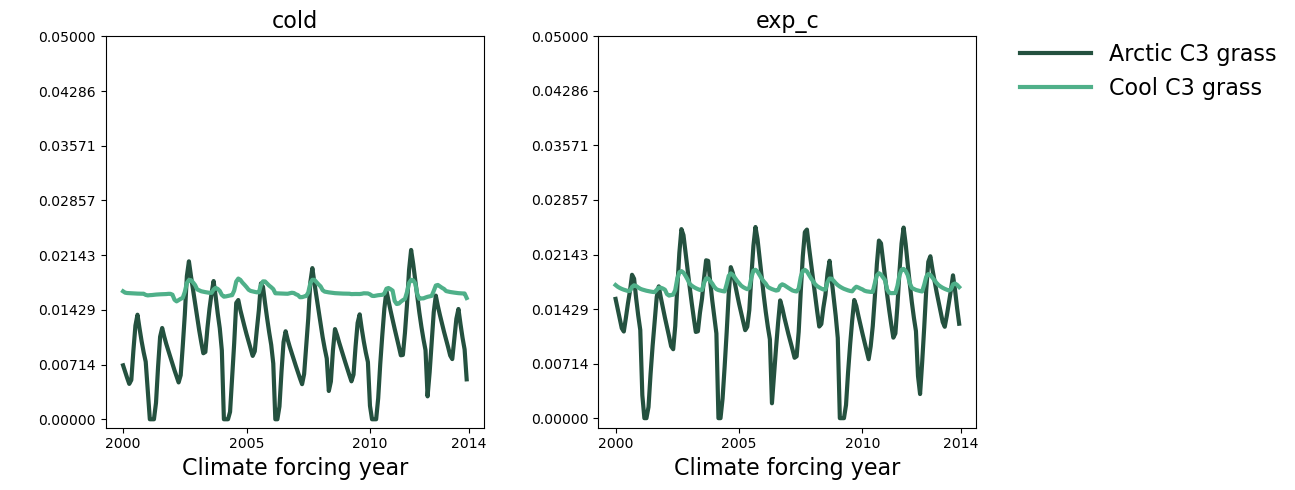

In [ ]:
# list simulations to include
simulations = ['cold', #'warm',
               'exp_c'#,'exp_w'
               ]

# Instantiate plot
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(10, 5)
)

# Plot in loop
for i, simulation in enumerate(simulations):
    ax = axes[i]  # Get the appropriate axis object for the current subplot
    
    # subset variable from data
    pft_biomass = subset[simulation]["FATES_VEGC_PF"]
    
    # Create a multi-line plot by looping through PFT properties
    plot_handle_list = []
    
    # Use default PFT dictionary
    pft_dict = fates_pft_dict
    
    for cur_pft_idx in pft_biomass.fates_levpft:
        
        cur_pft_dict = pft_dict[str(int(cur_pft_idx))]
        
        # Plot biomass for current PFT index
        cur_plot_handles, = ax.plot(range(len(pft_biomass["time"])),
                                    pft_biomass.sel(fates_levpft=cur_pft_idx),
                                    label=cur_pft_dict["long_name"],
                                    linestyle="-",
                                    linewidth=3,
                                    color=cur_pft_dict["colour"]
                                   )
        
        plot_handle_list.append(cur_plot_handles)
    
    # Set overall plot layout
    ax.set_title(f"{simulation}", fontsize=16)
    ax.set_xlabel("Climate forcing year", fontsize=16)
    ax.set_ylabel(f" ", fontsize=16) # overwrite manually in composite figure. Alternative: "Biomass per PFT [{pft_biomass.units}]"
    
    # set the y axis length
    ax.set_yticks(np.linspace(0, 0.05, num=8))    

    # Set x-axis tick labels
    ax.set_xticks(tick_locations)
    ax.set_xticklabels(labels)

# Create a single legend for all subplots
fig.legend(
    handles=plot_handle_list,
    bbox_to_anchor=(1.005, 0.945),  # Places the legend outside to the plotting area
    loc='upper left',
    frameon=False,
    handlelength=3.2,
    fontsize=16
)

plt.tight_layout()  # Adjust spacing between subplots
plt.show()  # Show the plot

---
# Plot productivity/fluxes per PFT

Variables:

- FATES_GPP: gross primary production in kg carbon per m2 per second
- FATES_AUTORESP: autotrophic respiration in kg carbon per m2 per second
- FATES_HET_RESP: heterotrophic respiration in kg carbon per m2 per second
- FATES_NEP: net ecosystem production in kg carbon per m2 per second

## Boxplots of GPP, NPP, respiration

Start by subsetting data for the relevant variables, converting from monthly to yearly values, and subset the last 10 years of simulation. Takes 3-5 mins.

In [39]:
# define which simulations to include
simulations = ['cold', #'warm',
               'exp_c'#,'exp_w'
               ]

# define output variables to include
c_flux_var_names = [
    "FATES_GPP",
    "FATES_AUTORESP",
    "FATES_HET_RESP",
    "FATES_NEP"
]

# Dictionary to store dataframes for each simulation
dfs = {}  

# do data handling in loop for all the simulations
for sim in simulations:
    c_flux_vars = [data[sim][name] for name in c_flux_var_names]
    # Convert to yearly output. 
    # Monthly output, averaged for unit kg C m-2 s-1. To convert to total yearly (kg C m-2 yr-1):
    # 1 month on average = 2,628,288 seconds, sum up monthly values
    c_flux_vars_annual = [(var * 2628288).resample(time='1Y').sum(keep_attrs=True) for var in c_flux_vars]
    #Subset last 14 years
    n_years = 14
    c_fluxes_last_14y = [var.values.flatten()[-n_years-1:-1] for var in c_flux_vars_annual]
    # Create DataFrame
    c_fluxes_df = pd.DataFrame(columns=[var.name for var in c_flux_vars])
    
    for idx, var in enumerate(c_fluxes_df.columns):
        c_fluxes_df[var] = c_fluxes_last_14y[idx]
    # store in dictionary
    dfs[sim] = c_fluxes_df

# Example
dfs['cold']

,FATES_GPP,FATES_AUTORESP,FATES_HET_RESP,FATES_NEP
0,0.001339,0.003838,0.204592,-0.206997
1,0.000000,0.005733,0.204797,-0.210434
2,0.000036,0.003491,0.197031,-0.200407
3,0.009355,0.009391,0.170174,-0.170109
4,0.001870,0.008487,0.181718,-0.188217
5,0.010082,0.006201,0.158125,-0.154142
6,0.005214,0.009310,0.189180,-0.193170
7,0.000186,0.003798,0.211580,-0.215099
8,0.008307,0.009360,0.206940,-0.207887
9,0.000004,0.005012,0.204819,-0.209725


In [40]:
# Set general plotting options
TICK_LABEL_FONT_SIZE = 11
AX_LABEL_FONT_SIZE = 12

### plot C fluxes per simulation

In [41]:
# Iterate over simulations and create plots
for sim, df in dfs.items():
    # Instantiate plot
    fig, ax = plt.subplots(figsize=(5, 5), dpi=150)
    
    box_plot = ax.boxplot(
        df,
        patch_artist=True,
        medianprops={
            'linewidth': 2,
            'color': 'black'
        }
    )

    box_color = '#28282B80'
    for patch in box_plot['boxes']:
        patch.set_facecolor(box_color)

    x_labels = [
        "GPP",
        r"R$_{A}$",
        r"R$_{H}$",
        "NEP"
    ]

    ax.set_title(sim)
    ax.set_xticklabels(x_labels, fontsize=AX_LABEL_FONT_SIZE - 1)
    ax.set_ylabel("Total annual flux\n(kg C / m² / year)", fontsize=AX_LABEL_FONT_SIZE)
    ax.tick_params(axis='y', which='major', labelsize=TICK_LABEL_FONT_SIZE)
    ax.tick_params(axis='x', which='major', labelsize=AX_LABEL_FONT_SIZE)

    # Manually set y-ticks
    max_y = max(ax.get_yticks())
    min_y = min(ax.get_yticks())
    ax.set_yticks(np.linspace(min_y, max_y, num=5))

    # Save figure
    fig.tight_layout()
    fig.savefig(fname=f"{plot_save_path}/modelled_c_fluxes_{sim}.png", format='png')
    plt.close(fig)  # Close the figure to free up memory

In [42]:
plot_save_path

WindowsPath('../../results/figures')

Same but with all the plots in a grid:

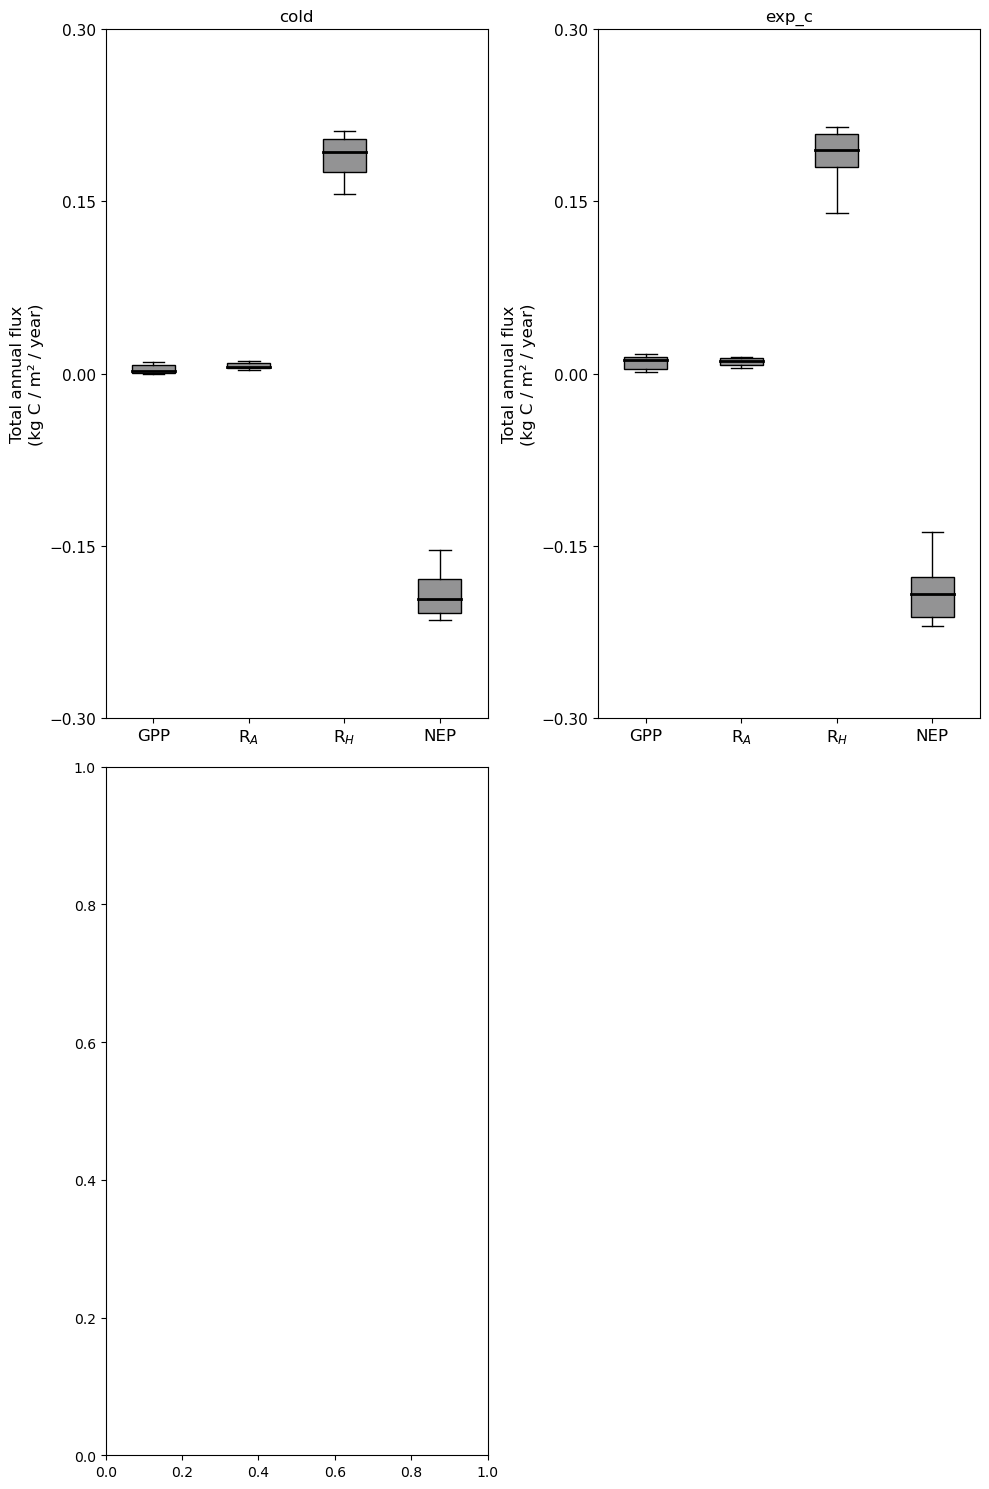

In [43]:
# Instantiate figure with individual figures next to each other
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(10, 15)
)

# Delete empty axis object if number of simulations in list is odd
if len(axes.flatten()) != len(simulations):
    if len(axes.flatten()) == 2:
        fig.delaxes(axes[-1])
    else:
        fig.delaxes(axes[-1, -1])

for index, (sim, df) in enumerate(dfs.items()):
    # Instantiate plot
    ax = axes[index // 2, index % 2]  # Get the appropriate axis object for the current subplot
        
    box_plot = ax.boxplot(
        df,
        patch_artist=True,
        medianprops={
            'linewidth': 2,
            'color': 'black'
        }
    )

    box_color = '#28282B80'
    for patch in box_plot['boxes']:
        patch.set_facecolor(box_color)

    x_labels = [
        "GPP",
        r"R$_{A}$",
        r"R$_{H}$",
        "NEP"
    ]

    ax.set_title(sim)
    ax.set_xticklabels(x_labels, fontsize=AX_LABEL_FONT_SIZE - 1)
    ax.set_ylabel("Total annual flux\n(kg C / m² / year)", fontsize=AX_LABEL_FONT_SIZE)
    ax.tick_params(axis='y', which='major', labelsize=TICK_LABEL_FONT_SIZE)
    ax.tick_params(axis='x', which='major', labelsize=AX_LABEL_FONT_SIZE)

    # Manually set y-ticks
    max_y = max(ax.get_yticks())
    min_y = min(ax.get_yticks())
    ax.set_yticks(np.linspace(min_y, max_y, num=5))

fig.tight_layout()
plt.show()


## Figure 4

Same data, but displayed per variable instead of per simulation:

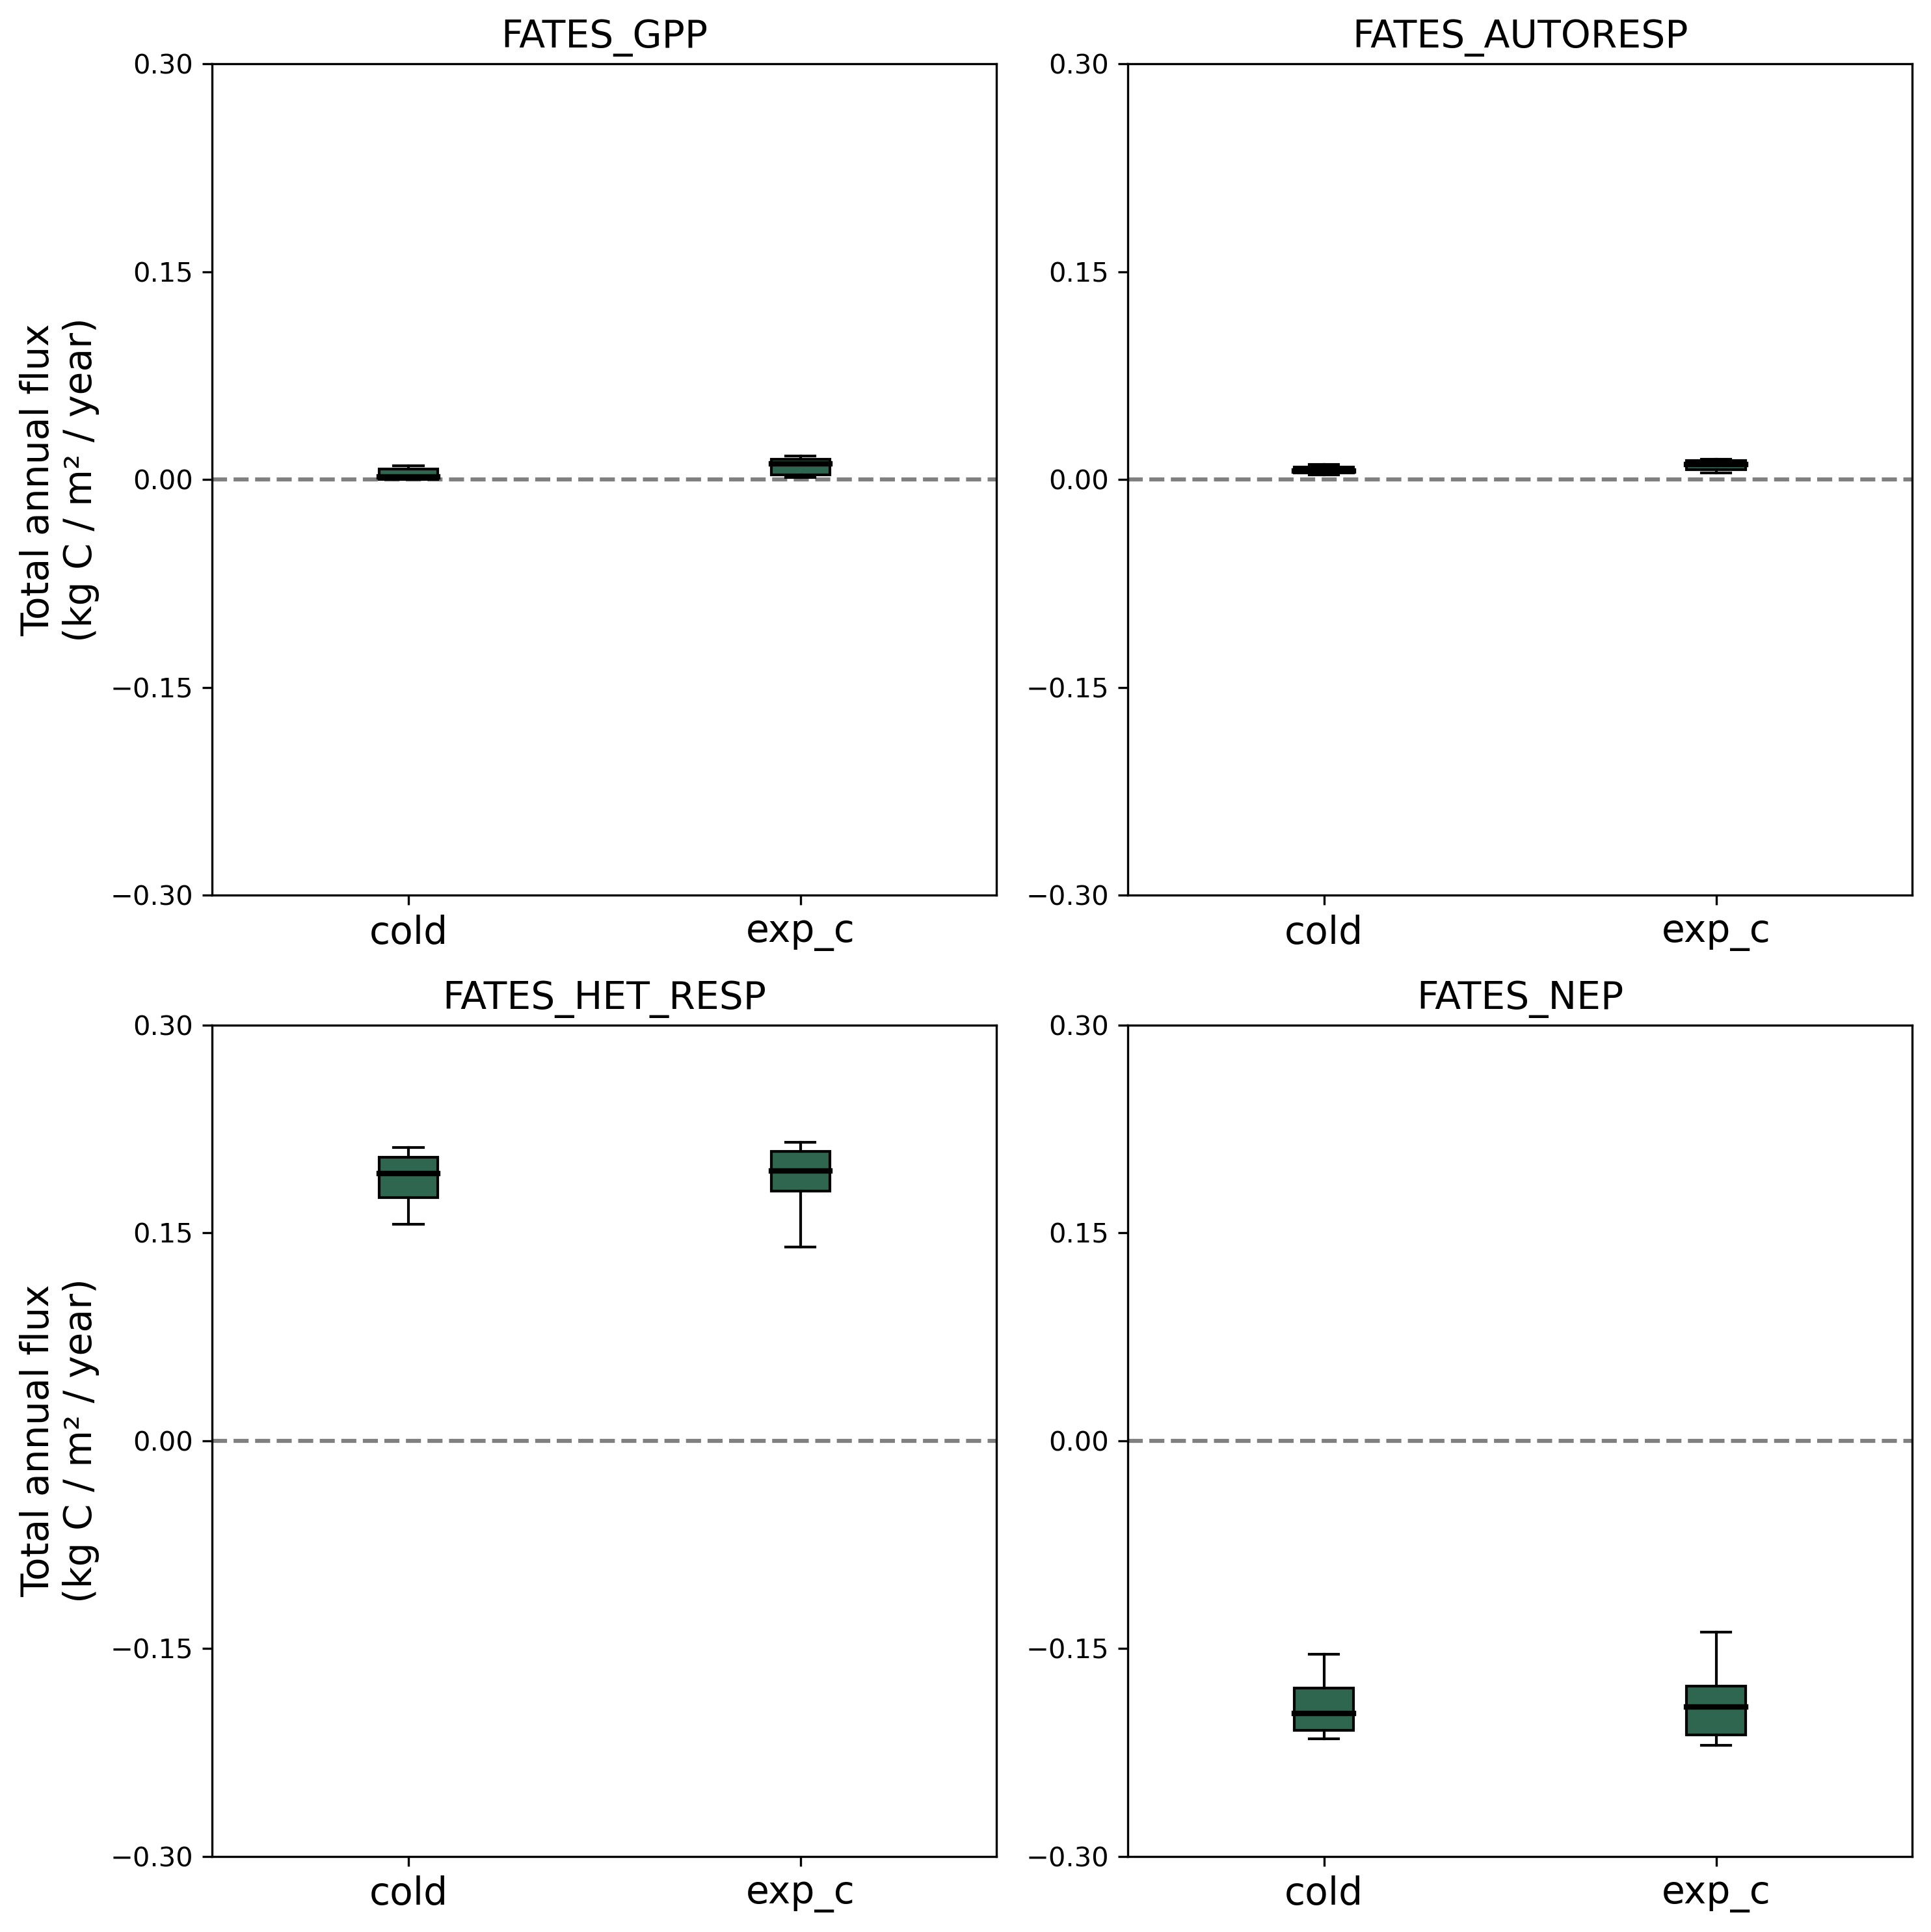

In [ ]:
# Instantiate figure with individual figures next to each other
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(10, 10),
    dpi=300
)

variables = [
    "FATES_GPP",
    "FATES_AUTORESP",
    "FATES_HET_RESP",
    "FATES_NEP"
]

for index, variable in enumerate(variables):
    # Instantiate plot
    ax = axes[index // 2, index % 2]  # Get the appropriate axis object for the current subplot

    data = [df[variable] for df in dfs.values()]  # Get the data for the current variable from all datasets

    box_plot = ax.boxplot(
        data,
        patch_artist=True,
        medianprops={
            'linewidth': 2,
            'color': 'black'
        }
    )

    box_color = '#2E6650'
    for patch in box_plot['boxes']:
        patch.set_facecolor(box_color)

    x_labels = [sim for sim in dfs.keys()]  # Use simulation names as x-axis labels

    ax.set_title(variable, fontsize=AX_LABEL_FONT_SIZE+2) # Alternative: variable
    ax.set_xticklabels(x_labels, fontsize=AX_LABEL_FONT_SIZE)
    ax.tick_params(axis='x', which='major', labelsize=AX_LABEL_FONT_SIZE+2)

    # Manually set y-ticks
    ax.set_yticks(np.linspace(-0.3, 0.3, num=5))
    # Might need color/transparency adjustment
    ax.axhline(y=0, color='grey', linestyle='dashed', zorder=-1)

    # Only show the y-axis label for plots 1 and 3
    if index in [0, 2]:
        ax.set_ylabel("Total annual flux\n(kg C / m² / year)", fontsize=AX_LABEL_FONT_SIZE+2)
    else:
        ax.set_ylabel("")  # Empty string to hide the label

fig.tight_layout()
plt.show()


-----------------

## LAI, snow depth, snowfree days and soil temperature

Explore and plot some additional variables that might give insight into the growing conditions. Start by subsetting data for the relevant variables, converting from monthly to yearly values, and subset the last 14 years of simulation. 

In [62]:
# re-read data if necessary
file_paths = {
    'cold': file_path_cold,
#    'warm': file_path_warm,
    'exp_c': file_path_exp_c#,
#    'exp_w': file_path_exp_w
}

data = {}

for dataset, path in file_paths.items():
    data[dataset] = xr.open_mfdataset(path, 
                                      combine='by_coords', 
                                      decode_times=True)

In [52]:
# define which simulations to include
simulations = ['cold', #'warm',
               'exp_c'#,'exp_w'
               ]

# define output variables to include
var_names = [
    "ELAI",
    "SNOW_DEPTH",
    "TSOI_10CM",
    "FATES_GDD"
]

# Dictionary to store dataframes for each simulation
dfs2 = {}  

# do data handling in loop for all the simulations
for sim in simulations:
    vars = [data[sim][name] for name in var_names]
    # Convert to yearly output. 
    # Monthly output. To convert to total yearly:
    # 1 month on average = 2,628,288 seconds, sum up monthly values
    vars_annual = [(var * 2628288).resample(time='1Y').sum(keep_attrs=True) for var in vars]
    #Subset last 14 years
    n_years = 14
    last_14y = [var.values.flatten()[-n_years-1:-1] for var in vars_annual]
    # Create DataFrame
    vars_df = pd.DataFrame(columns=[var.name for var in vars])
    
    for idx, var in enumerate(vars_df.columns):
        vars_df[var] = last_14y[idx]
    # store in dictionary
    dfs2[sim] = vars_df

# Example:
dfs2['cold']

,ELAI,SNOW_DEPTH,TSOI_10CM,FATES_GDD
0,204976.542847,7.793955e+07,8.743315e+09,0.000000e+00
1,217346.040841,1.214191e+08,8.734946e+09,3.618107e+04
2,173896.665352,1.304962e+08,8.716752e+09,7.063216e+05
3,450883.121167,3.866994e+07,8.733702e+09,0.000000e+00
4,329243.671474,8.966036e+07,8.758008e+09,0.000000e+00
5,525605.909412,5.446349e+07,8.733853e+09,1.784908e+06
6,345684.622357,6.849607e+07,8.739773e+09,2.552309e+06
7,197305.891695,1.292011e+08,8.729307e+09,1.928550e+05
8,417271.073598,5.343235e+07,8.767470e+09,1.206672e+05
9,209772.173842,1.230600e+08,8.740720e+09,5.971165e+05


<AxesSubplot: >

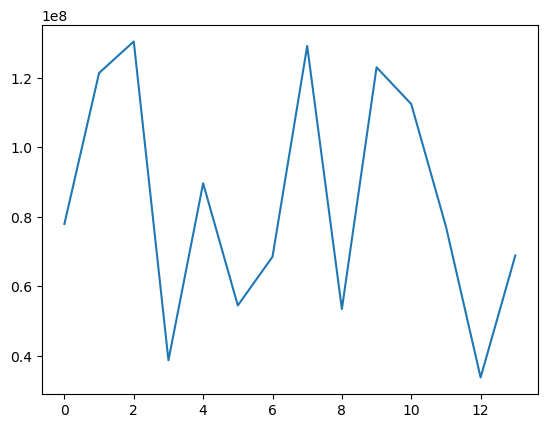

In [53]:
# quick plot. Vary simulation name and variable to compare. 
dfs2['cold']['SNOW_DEPTH'].plot()

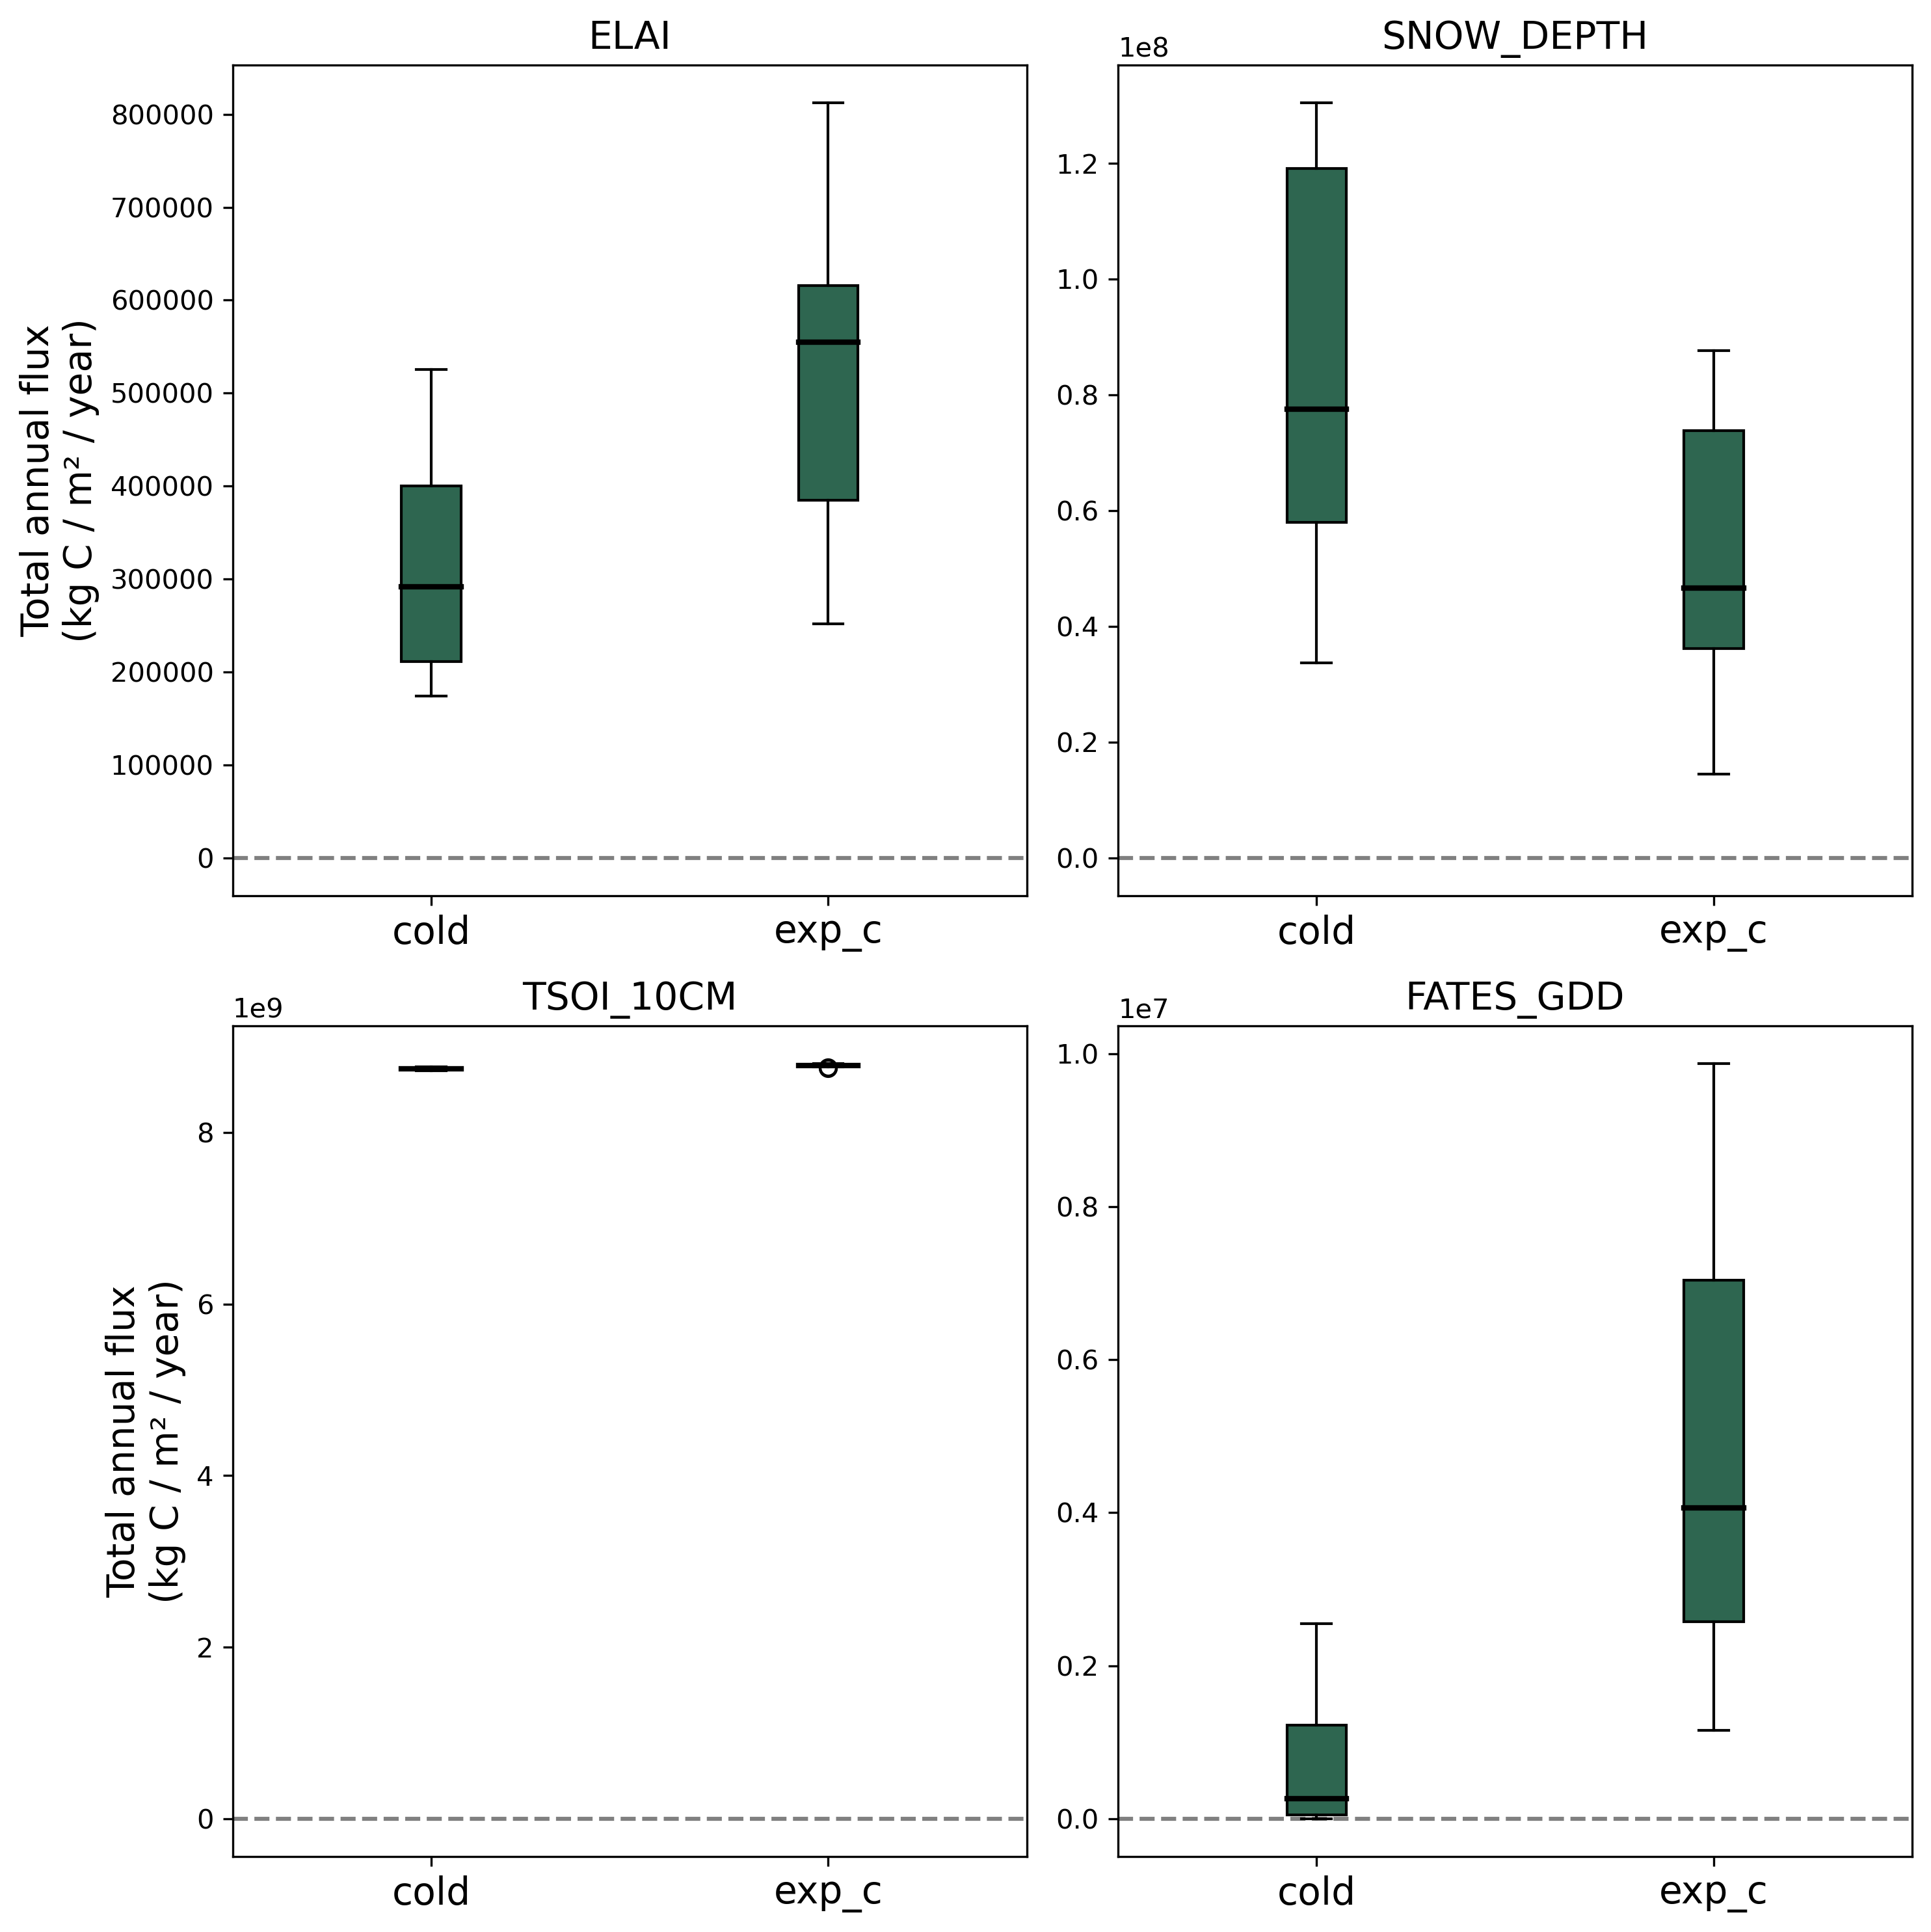

In [ ]:
# Instantiate figure with individual figures next to each other
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(10, 10),
    dpi=300
)

for index, variable in enumerate(var_names):
    # Instantiate plot
    ax = axes[index // 2, index % 2]  # Get the appropriate axis object for the current subplot

    data = [df[variable] for df in dfs2.values()]  # Get the data for the current variable from all datasets

    box_plot = ax.boxplot(
        data,
        patch_artist=True,
        medianprops={
            'linewidth': 2,
            'color': 'black'
        }
    )

    box_color = '#2E6650'
    for patch in box_plot['boxes']:
        patch.set_facecolor(box_color)

    x_labels = [sim for sim in dfs.keys()]  # Use simulation names as x-axis labels

    ax.set_title(variable, fontsize=AX_LABEL_FONT_SIZE+2) # Alternative: variable
    ax.set_xticklabels(x_labels, fontsize=AX_LABEL_FONT_SIZE)
    ax.tick_params(axis='x', which='major', labelsize=AX_LABEL_FONT_SIZE+2)

    # Let y axis be set automatically
    # Might need color/transparency adjustment
    ax.axhline(y=0, color='grey', linestyle='dashed', zorder=-1)

    # Only show the y-axis label for plots 1 and 3
    if index in [0, 2]:
        ax.set_ylabel("Total annual flux\n(kg C / m² / year)", fontsize=AX_LABEL_FONT_SIZE+2)
    else:
        ax.set_ylabel("")  # Empty string to hide the label

fig.tight_layout()
plt.show()

------------
## line plots over time

re-read data if necessary

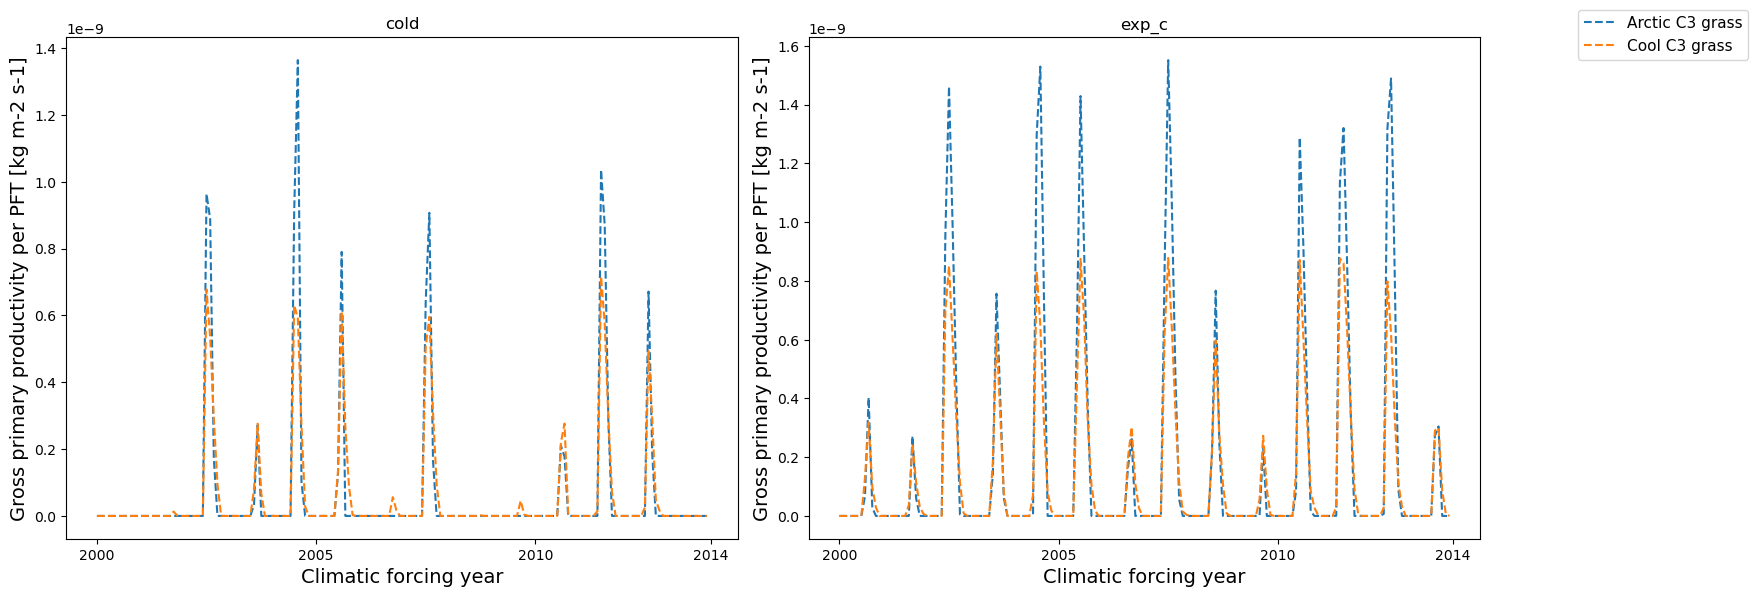

In [60]:
import matplotlib.pyplot as plt

# list simulations to include
simulations = ['cold', #'warm',
               'exp_c'#,'exp_w'
               ]

# Instantiate plot
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 6)
)

# Plot in loop
for i, simulation in enumerate(simulations):
    ax = axes[i]  # Get the appropriate axis object for the current subplot
    
    # subset variable from data
    pft_biomass = subset[simulation]["FATES_GPP_PF"]
    
    # Create a multi-line plot by looping through PFT properties
    plot_handle_list = []
    
    # Use default PFT dictionary
    pft_dict = fates_pft_dict
    
    for cur_pft_idx in pft_biomass.fates_levpft:
        
        cur_pft_dict = pft_dict[str(int(cur_pft_idx))]
        
        # Plot biomass for current PFT index
        cur_plot_handles, = ax.plot(range(len(pft_biomass["time"])),
                                    pft_biomass.sel(fates_levpft=cur_pft_idx),
                                    label=cur_pft_dict["long_name"],
                                    linestyle="--",
                                    linewidth=1.5
                                   )
        
        plot_handle_list.append(cur_plot_handles)
    
    # Set overall plot layout
    ax.set_title(f"{simulation}")
    ax.set_xlabel("Climatic forcing year", fontsize=14)
    ax.set_ylabel(f"Gross primary productivity per PFT [{pft_biomass.units}]", fontsize=14)

    # Set x-axis tick labels 
    ax.set_xticks(tick_locations)
    ax.set_xticklabels(labels)

# Create a single legend for all subplots
fig.legend(
    handles=plot_handle_list,
    bbox_to_anchor=(1.05, 1),  # Places the legend outside to the plotting area
    loc='upper left',
    fontsize=11
)

plt.tight_layout()  # Adjust spacing between subplots
plt.show()  # Show the plot
